<a href="https://colab.research.google.com/github/Yong-Zone/-/blob/master/Chest_X_Ray_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mlflow gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yutsungtai","key":"036eee9a5882077cdfab414ffaa27a9a"}'}

上傳kaggle 的 API

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

設定我的權限，僅運許自己可以使用這一個token 的api

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:11<00:00, 18.8MB/s]



In [ ]:
!unzip chest-xray-pneumonia.zip -d chest_xray

串流輸出內容已截斷至最後 5000 行。
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  

In [ ]:
import os

base_dir = '/content/chest_xray/chest_xray'

for split in ['train', 'test', 'val']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} 張")

train/NORMAL: 1341 張
train/PNEUMONIA: 3875 張
test/NORMAL: 234 張
test/PNEUMONIA: 390 張
val/NORMAL: 8 張
val/PNEUMONIA: 8 張


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/content/chest_xray/chest_xray'

In [ ]:
# 訓練集：做資料增強 + 正規化
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# 測試/驗證集：只做正規化
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    base_dir + '/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    base_dir + '/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_gen = test_datagen.flow_from_directory(
    base_dir + '/val',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("類別對應：", train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
類別對應： {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # 第一層卷積
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # 第二層卷積
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # 第三層卷積
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # 全連接層
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 二元分類
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,609 (36.49 MB)

 Trainable params: 9,564,161 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

class_weight = {0: 3875/1341, 1: 1.0}

# 存在 Colab 本地
checkpoint = ModelCheckpoint(
    '/content/chest_xray_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stop]
)

NameError: name 'model' is not defined

In [ ]:
import os
if os.path.exists('/content/chest_xray'):
    print("資料還在！")
else:
    print("資料不見了，需要重新下載")

資料不見了，需要重新下載


In [ ]:
from google.colab import files
uploaded = files.upload()  # 選你電腦裡的 chest_xray_best_model.h5

Saving chest_xray_best_model.h5 to chest_xray_best_model.h5


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/chest_xray_best_model.h5')
print("模型載入成功！")
model.summary()

模型載入成功！


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,611 (36.49 MB)

 Trainable params: 9,564,161 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 589ms/step - accuracy: 0.8942 - loss: 0.2882

Test Accuracy: 89.42%
Test Loss: 0.2882
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.40      0.38      0.39       234
   PNEUMONIA       0.64      0.67      0.65       390

    accuracy                           0.56       624
   macro avg       0.52      0.52      0.52       624
weighted avg       0.55      0.56      0.55       624



/tmp/ipykernel_1047/974020864.py:30: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png')
/tmp/ipykernel_1047/974020864.py:30: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png')
/tmp/ipykernel_1047/974020864.py:30: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png')
/tmp/ipykernel_1047/974020864.py:30: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969

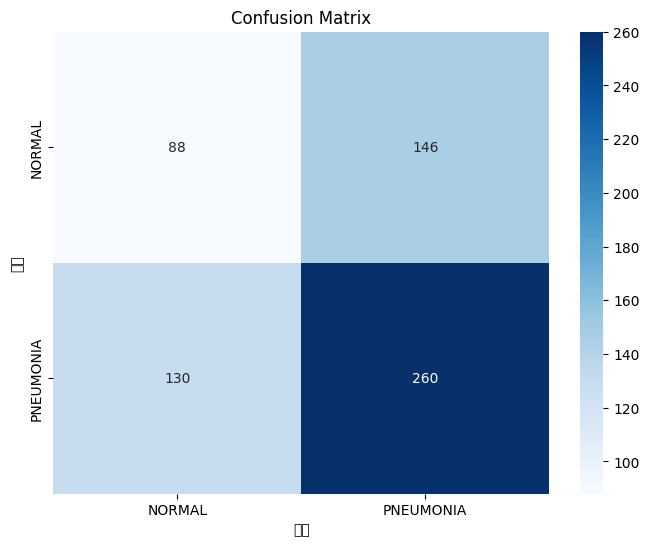

Confusion Matrix 已儲存！


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 在 test set 上評估
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 取得預測結果
test_gen.reset()
y_pred = model.predict(test_gen)
y_pred_labels = (y_pred > 0.5).astype(int).flatten()
y_true = test_gen.classes

# 印出詳細報告
print("\nClassification Report:")
print(classification_report(y_true, y_pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

# 畫 Confusion Matrix
cm = confusion_matrix(y_true, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix')
plt.ylabel('實際')
plt.xlabel('預測')
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion Matrix 已儲存！")

In [ ]:
from google.colab import files
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("模型建立完成！")

模型建立完成！


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

class_weight = {0: 3875/1341, 1: 1.0}

checkpoint = ModelCheckpoint(
    '/content/chest_xray_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8197 - loss: 4.4970
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/chest_xray_best_model.h5



Epoch 1: finished saving model to /content/chest_xray_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 422ms/step - accuracy: 0.8687 - loss: 1.5629 - val_accuracy: 0.5000 - val_loss: 39.0644
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9176 - loss: 0.3219
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 429ms/step - accuracy: 0.9218 - loss: 0.3229 - val_accuracy: 0.5000 - val_loss: 12.8697
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9285 - loss: 0.3093
Epoch 3: val_accuracy improved from 0.50000 to 0.68750, saving model to /content/chest_xray_best_model.h5



Epoch 3: finished saving model to /content/chest_xray_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 418ms/step - accuracy: 0.9323 - loss: 0.2914 - val_accuracy: 0.6875 - val_loss: 0.7039
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9269 - loss: 0.2958
Epoch 4: val_accuracy did not improve from 0.68750
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 416ms/step - accuracy: 0.9354 - loss: 0.2698 - val_accuracy: 0.5000 - val_loss: 12.6446
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9242 - loss: 0.3514
Epoch 5: val_accuracy improved from 0.68750 to 0.81250, saving model to /content/chest_xray_best_model.h5



Epoch 5: finished saving model to /content/chest_xray_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 417ms/step - accuracy: 0.9291 - loss: 0.3118 - val_accuracy: 0.8125 - val_loss: 0.4218
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9362 - loss: 0.2703
Epoch 6: val_accuracy improved from 0.81250 to 0.93750, saving model to /content/chest_xray_best_model.h5



Epoch 6: finished saving model to /content/chest_xray_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 421ms/step - accuracy: 0.9363 - loss: 0.2514 - val_accuracy: 0.9375 - val_loss: 0.3021
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9361 - loss: 0.2481
Epoch 7: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 419ms/step - accuracy: 0.9373 - loss: 0.2508 - val_accuracy: 0.8125 - val_loss: 0.6400
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9414 - loss: 0.2400
Epoch 8: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.9473 - loss: 0.2133 - val_accuracy: 0.5625 - val_loss: 0.6630
Epoch 9/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9391 - loss: 0.2324
Epoch 9: val_accuracy did not improve from 0.93750
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9392 - loss: 0.2234 - val_accuracy: 0.5625 - val_loss: 1.1822
Epoch 10/30
163/163 ━━━━━━━━━━━━━━

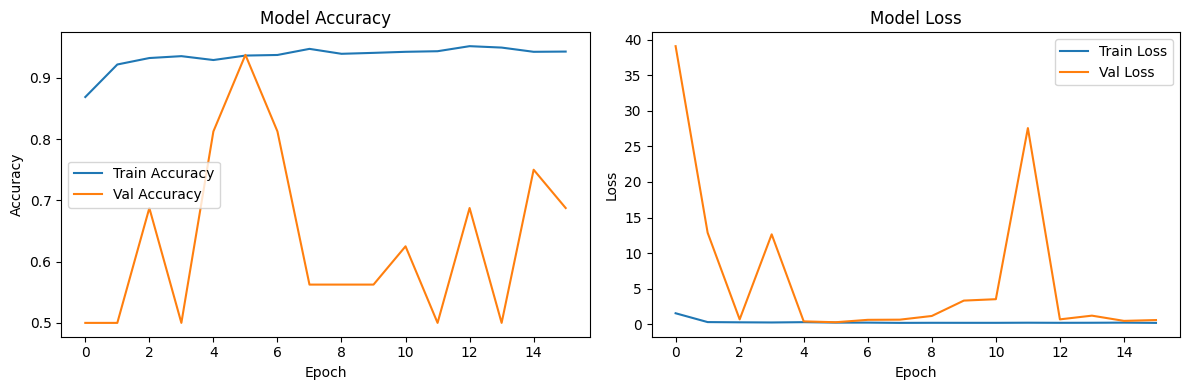

訓練曲線圖已儲存！


In [ ]:
import matplotlib.pyplot as plt

# 畫 Accuracy 曲線
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 畫 Loss 曲線
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print("訓練曲線圖已儲存！")

In [ ]:
from google.colab import files
files.download('training_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

def predict_pneumonia(img):
    img = img.resize((150, 150))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "🔴 PNEUMONIA（肺炎）"
        confidence = prediction * 100
    else:
        label = "🟢 NORMAL（正常）"
        confidence = (1 - prediction) * 100

    return f"{label}\n信心度：{confidence:.2f}%"

demo = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil", label="上傳 X-Ray 圖片"),
    outputs=gr.Textbox(label="診斷結果", lines=5),  # lines 調大輸出框
    title="肺炎 X-Ray 診斷系統",
    description="上傳胸腔 X-Ray 圖片，AI 自動判斷是否為肺炎"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3bac5dd7db0248818a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os

# 看 NORMAL 資料夾裡的前3個檔案
normal_files = os.listdir('/content/chest_xray/chest_xray/test/NORMAL')
print("NORMAL:", normal_files[:3])

# 看 PNEUMONIA 資料夾裡的前3個檔案
pneumonia_files = os.listdir('/content/chest_xray/chest_xray/test/PNEUMONIA')
print("PNEUMONIA:", pneumonia_files[:3])

NORMAL: ['NORMAL2-IM-0285-0001.jpeg', 'NORMAL2-IM-0339-0001.jpeg', 'IM-0059-0001.jpeg']
PNEUMONIA: ['person32_virus_71.jpeg', 'person50_virus_102.jpeg', 'person83_bacteria_412.jpeg']


In [ ]:
import shutil

# 複製一張正常的
shutil.copy(
    '/content/chest_xray/chest_xray/test/NORMAL/NORMAL2-IM-0285-0001.jpeg',
    '/content/normal_sample.jpeg'
)

# 複製一張肺炎的
shutil.copy(
    '/content/chest_xray/chest_xray/test/PNEUMONIA/person32_virus_71.jpeg',
    '/content/pneumonia_sample.jpeg'
)

print("複製完成！")

複製完成！


In [ ]:
from google.colab import files
files.download('/content/pneumonia_sample.jpeg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import files

files.download('/content/chest_xray_best_model.h5')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()  # 選 chest_xray_best_model.h5

Saving model.h5 to model.h5


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = tf.keras.models.load_model('/content/model.h5')
print("模型載入成功！")

base_dir = '/content/chest_xray/chest_xray'
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    base_dir + '/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
print("資料載入完成！")

模型載入成功！
Found 624 images belonging to 2 classes.
資料載入完成！


In [ ]:
from google.colab import files
files.upload()  # 選 confusion_matrix.png 和 training_curves.png（可以同時選兩個）

Saving training_curves.png to training_curves.png
Saving confusion_matrix.png to confusion_matrix.png


{'training_curves.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0\x00\x00\x01\x90\x08\x06\x00\x00\x00\xbe\xb5\x99^\x00\x00\x00:tEXtSoftware\x00Matplotlib version3.10.0, https://matplotlib.org/\x94rXr\x00\x00\x00\tpHYs\x00\x00\x0fa\x00\x00\x0fa\x01\xa8?\xa7i\x00\x00\xccYIDATx\x9c\xec\xddwx\x14\xe5\xda\xc7\xf1\xef\xa6\xf7\x84@B\x08\x84\xde1\xf4b9**\x8a\xa0\x88\x08JQ\x11D9*\xa8\x88z<\xa8\x07\xb0\xe2\xb1\xbf*\xea\x11)\x16\x8a\x82\r+"J\x11\xa5\x1b\x11A\xa4\xb7\x90BIBz\xb2\xbb\xef\x1f\x93\xdd$\x10 !\x9b\x9dM\xf2\xfb\\\xd7^3\x99\x9d\x9d\xb97\xc02{\xcf\xfd\xdc\x8f\xc5n\xb7\xdb\x11\x11\x11\x11\x11\x11\x11\x11\x11\xf1P^f\x07 """"""""r&J`\x89\x88\x88\x88\x88\x88\x88\x88\x88GS\x02KDDDDDDDD<\x9a\x12X""""""""\xe2\xd1\x94\xc0\x12\x11\x11\x11\x11\x11\x11\x11\x11\x8f\xa6\x04\x96\x88\x88\x88\x88\x88\x88\x88\x88x4%\xb0DDDDDDDD\xc4\xa3)\x81%""""""""\x1eM\t,\x11\x11\x11\x11\x11\x11\x11\x11\xf1hJ`\x89\x88\x88\x88\x88\x88\x88\x88\x88GS\x02KDDDDDDDD<\x9a\x12X""""""""\xe2\xd1\x94\xc0\x12\x11\x11\x1

In [ ]:
!pip install mlflow -q
import mlflow

# 開始記錄實驗
mlflow.set_experiment("chest_xray_pneumonia")

with mlflow.start_run():
    # 記錄模型參數
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("input_size", "150x150")
    mlflow.log_param("epochs_trained", 16)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("class_weight", "NORMAL:2.89, PNEUMONIA:1.0")

    # 記錄模型結果
    mlflow.log_metric("val_accuracy", 0.9375)
    mlflow.log_metric("test_accuracy", 0.8942)
    mlflow.log_metric("test_loss", 0.2882)

    # 記錄圖片
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_artifact("training_curves.png")

    print("MLflow 記錄完成！")

MLflow 記錄完成！
